# LAB 5 - MÉTODOS NUMÉRICOS - ANTÔNIO VINÍCIUS LIBERATO OLIVEIRA SIEBRA - 610619

Importando as bibliotecas padrões necessárias para o laboratório neste nível superior.

In [2]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
from statsmodels.api import OLS
import sklearn.model_selection as skm
import sklearn.linear_model as skl
from sklearn.preprocessing import StandardScaler
from ISLP.models import ModelSpec as MS
from functools import partial

Importações adicionais necessárias para a criação de pipelines, PCA, regressão PLS e funções para o caminho de seleção. Para a seleção do melhor subconjunto, o livro utiliza a biblioteca `l0bnb`; porém, ela é incompatível com as versões atuais do NumPy (2.x) e do Numba. Como o nosso dataset possui apenas 3 preditores (apenas $2^3 - 1 = 7$ combinações possíveis), utilizamos o módulo `itertools` para realizar a busca exaustiva, que fornece exatamente o mesmo resultado (o melhor subconjunto de cada tamanho).

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from ISLP.models import \
(Stepwise,
sklearn_selected,
sklearn_selection_path)
from itertools import combinations

Carregando o conjunto de dados `dataset_regressao_limpo.csv` (geração de energia solar da Plant_1), removendo os espaços extras dos nomes das colunas e verificando a quantidade de valores ausentes (NaN) na variável resposta `DC_POWER` (potência em corrente contínua gerada pelos inversores). Os preditores disponíveis são `AMBIENT_TEMPERATURE`, `MODULE_TEMPERATURE` e `IRRADIATION`.

In [4]:
df = pd.read_csv('dataset_regressao_limpo.csv')
df.columns = df.columns.str.strip() # Remove espaços extras nos nomes das colunas
np.isnan(df['DC_POWER']).sum()

np.int64(0)

Removendo todas as linhas que possuem valores ausentes utilizando dropna() e conferindo o formato do dataset. Como o dataset já passou por uma etapa de limpeza (`limpeza.py`), nenhuma linha é removida: são 68.774 observações e 4 colunas.

In [5]:
df = df.dropna();
df.shape

(68774, 4)

Definindo uma função para calcular a estatística Cp negativa, que servirá de métrica para a seleção do nosso modelo.

In [6]:
def nCp(sigma2, estimator, X, Y):
    "Negative Cp statistic"
    n, p = X.shape
    Yhat = estimator.predict(X)
    RSS = np.sum((Y - Yhat)**2)
    return -(RSS + 2 * p * sigma2) / n

Ajustando o modelo com todas as variáveis climáticas disponíveis para conseguir estimar a variância residual (sigma2) que a função de pontuação precisará.

In [7]:
design = MS(df.columns.drop('DC_POWER')).fit(df)
Y = np.array(df['DC_POWER'])
X = design.transform(df)
sigma2 = OLS(Y,X).fit().scale

Fixando o primeiro argumento (sigma2) na função através do partial(), adaptando-a para o formato que a biblioteca sklearn espera para o scorer.

In [8]:
neg_Cp = partial(nCp, sigma2)

Definindo a estratégia de busca com forward selection (seleção para a frente) até que as inclusões parem de melhorar a avaliação (first_peak).

In [9]:
strategy = Stepwise.first_peak(design,
                               direction='forward',
                               max_terms=len(design.terms))

Ajustando um modelo de regressão linear usando a seleção forward baseada na métrica padrão (MSE), que resulta na seleção de todas as 3 variáveis climáticas (`AMBIENT_TEMPERATURE`, `IRRADIATION` e `MODULE_TEMPERATURE`).

In [10]:
solar_MSE = sklearn_selected(OLS, strategy)
solar_MSE.fit(df, Y)
solar_MSE.selected_state_

('AMBIENT_TEMPERATURE', 'IRRADIATION', 'MODULE_TEMPERATURE')

Ajustando a regressão com seleção forward usando nosso critério customizado neg_Cp, que restringe o modelo de forma mais rigorosa a um subconjunto de 2 variáveis (`IRRADIATION` e `MODULE_TEMPERATURE`), descartando a temperatura ambiente, cuja informação já está praticamente contida na temperatura do módulo.

In [11]:
solar_Cp = sklearn_selected(OLS, strategy, scoring=neg_Cp)
solar_Cp.fit(df, Y)
solar_Cp.selected_state_

('IRRADIATION', 'MODULE_TEMPERATURE')

Criando a estratégia para ajustar o caminho completo da seleção (todas as etapas para frente).

In [12]:
strategy = Stepwise.fixed_steps(design, len(design.terms), direction='forward')
full_path = sklearn_selection_path(OLS, strategy)

Ajustando o caminho completo e calculando a matriz de predições correspondentes ao número de passos (modelo nulo + 3 passos) e de amostras.

In [13]:
full_path.fit(df, Y)
Yhat_in = full_path.predict(df)
Yhat_in.shape

(68774, 4)

Plotando o MSE dentro da amostra (In-sample MSE) calculando a diferença ao quadrado em relação às respostas em cada passo do forward stepwise. Como o `DC_POWER` é medido em watts e chega a mais de 14.000, o MSE varia de cerca de $1,6 \times 10^7$ (modelo nulo) até $3,4 \times 10^5$; por isso usamos escala logarítmica no eixo vertical. Nota-se a queda brusca logo no 1º passo (inclusão da `IRRADIATION`), seguida de ganhos bem menores.

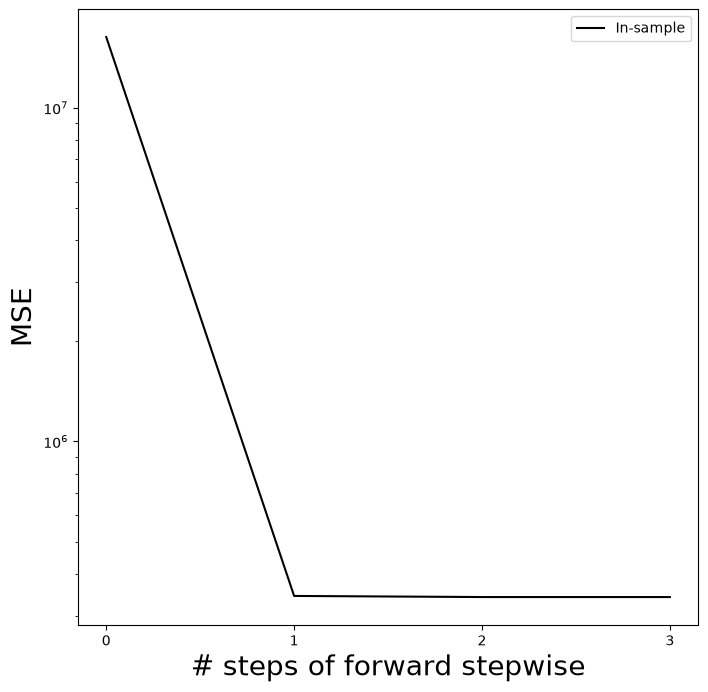

In [14]:
mse_fig, ax = subplots(figsize=(8,8))
insample_mse = ((Yhat_in - Y[:, None])**2).mean(0)
n_steps = insample_mse.shape[0]
ax.plot(np.arange(n_steps), insample_mse, 'k', label='In-sample')
ax.set_ylabel('MSE', fontsize=20)
ax.set_xlabel('# steps of forward stepwise', fontsize=20)
ax.set_xticks(np.arange(n_steps))
ax.legend()
ax.set_yscale('log');

Definindo a validação cruzada K-fold (K=5) e calculando as predições de teste (cross-validated predictions) para o caminho do modelo.

In [15]:
K = 5
kfold = skm.KFold(K, random_state=0, shuffle=True)
Yhat_cv = skm.cross_val_predict(full_path, df, Y, cv=kfold)
Yhat_cv.shape

(68774, 4)

Iterando sobre as dobras (folds) da validação cruzada para computar o erro quadrático médio em cada separação teste/treino.

In [16]:
cv_mse = []
for train_idx, test_idx in kfold.split(Y):
    errors = (Yhat_cv[test_idx] - Y[test_idx, None])**2
    cv_mse.append(errors.mean(0))
cv_mse = np.array(cv_mse).T
cv_mse.shape

(4, 5)

Adicionando os resultados da validação cruzada (curva média + erro padrão) ao nosso gráfico de MSE para visualizar o desempenho generalizado do modelo. Como temos muitas observações, as curvas de treino e de validação cruzada praticamente se sobrepõem.

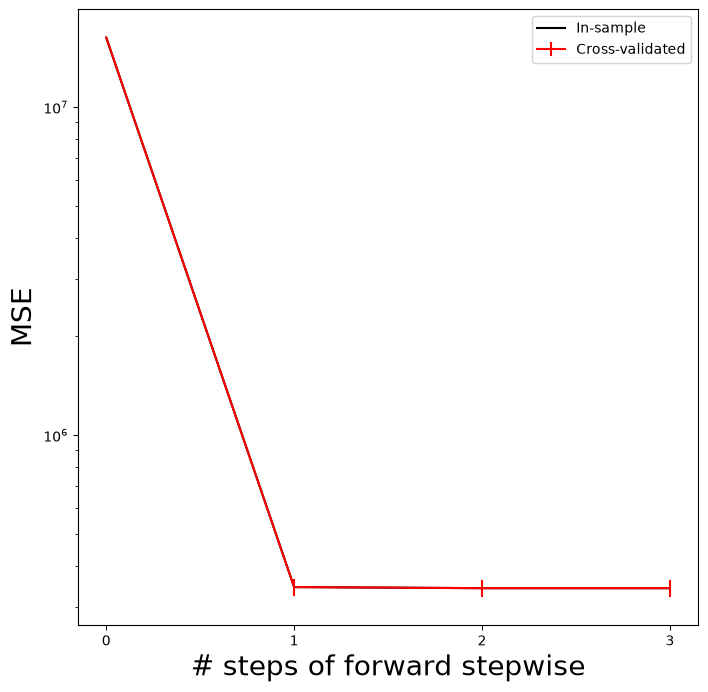

In [17]:
ax.errorbar(np.arange(n_steps), cv_mse.mean(1), cv_mse.std(1) / np.sqrt(K), label='Cross-validated', c='r')
ax.set_yscale('log')
ax.legend()
mse_fig

Realizando a mesma avaliação anterior, mas através de uma abordagem baseada em um conjunto de validação único (20% para teste).

In [18]:
validation = skm.ShuffleSplit(n_splits=1, test_size=0.2, random_state=0)
for train_idx, test_idx in validation.split(Y):
    full_path.fit(df.iloc[train_idx], Y[train_idx])
    Yhat_val = full_path.predict(df.iloc[test_idx])
    errors = (Yhat_val - Y[test_idx, None])**2
    validation_mse = errors.mean(0)

Atualizando o gráfico com a curva referente à abordagem do conjunto de validação único em azul pontilhado.

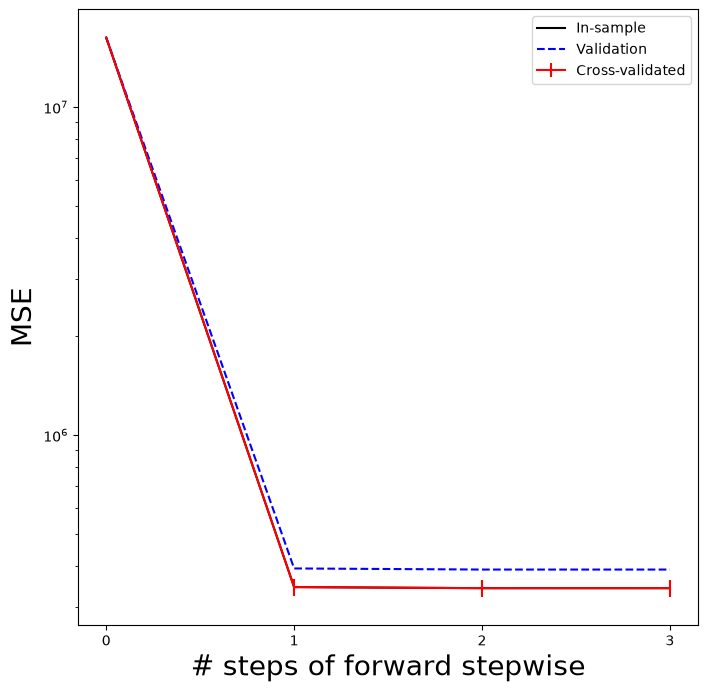

In [19]:
ax.plot(np.arange(n_steps), validation_mse, 'b--', label='Validation')
ax.set_xticks(np.arange(n_steps))
ax.set_yscale('log')
ax.legend()
mse_fig

Preparando os dados e transformando-os em matriz para realizar a seleção de melhor subconjunto (removendo a coluna do intercepto, que é tratada separadamente no ajuste).

In [20]:
D = design.fit_transform(df)
D = D.drop('intercept', axis=1)
X = np.asarray(D)

Gerando o caminho de subconjuntos através da seleção do melhor subconjunto (best subset selection). Para cada tamanho de modelo (1, 2 e 3 variáveis), todas as combinações possíveis de preditores são ajustadas por mínimos quadrados e é guardada aquela com a menor soma dos quadrados dos resíduos (RSS). O resultado é armazenado em uma lista de dicionários, no mesmo espírito da saída do `fit_path` da `l0bnb` (coeficientes `B`, intercepto `B0` e variáveis selecionadas).

In [21]:
path = []
for k in range(1, X.shape[1] + 1):
    melhor = None
    for subset in combinations(range(X.shape[1]), k):
        idx = list(subset)
        Xk = np.column_stack([np.ones(X.shape[0]), X[:, idx]])
        coef = np.linalg.lstsq(Xk, Y, rcond=None)[0]
        rss = np.sum((Y - Xk @ coef)**2)
        if melhor is None or rss < melhor['RSS']:
            B = np.zeros(X.shape[1])
            B[idx] = coef[1:]
            melhor = {'B': B, 'B0': coef[0], 'variaveis': list(D.columns[idx]), 'RSS': rss}
    path.append(melhor)
len(path)

3

Inspecionando o 2º elemento do caminho (melhor modelo com 2 variáveis), exibindo os coeficientes ajustados e as variáveis incluídas. Assim como na seleção forward com Cp, o melhor par de preditores é formado por `IRRADIATION` e `MODULE_TEMPERATURE`, com coeficiente zero para `AMBIENT_TEMPERATURE`.

In [22]:
path[1]

{'B': array([    0.        ,    15.20589268, 12630.22146857]),
 'B0': np.float64(-261.99465394609024),
 'variaveis': ['MODULE_TEMPERATURE', 'IRRADIATION'],
 'RSS': np.float64(23466885198.16546)}

Início da regressão Ridge: Centralização manual dos preditores climáticos, sua padronização de escala, e a extração do caminho de regularização via ElasticNet.path (com l1_ratio=0).

In [23]:
Xs = X - X.mean(0)[None,:]
X_scale = X.std(0)
Xs = Xs / X_scale[None,:]
lambdas = 10**np.linspace(8, -2, 100) / Y.std()
soln_array = skl.ElasticNet.path(Xs, Y, l1_ratio=0., alphas=lambdas)[1]
soln_array.shape

(3, 100)

Convertendo os coeficientes da regressão Ridge no formato tabular (DataFrame do Pandas), facilitando o índice com base em log negativo de lambda.

In [24]:
soln_path = pd.DataFrame(soln_array.T, columns=D.columns, index=-np.log(lambdas))
soln_path.index.name = 'negative log(lambda)'
soln_path

,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
negative log(lambda),,,
-10.117569,0.000000,0.000000,0.000000
-9.884985,0.000000,0.000000,0.000000
-9.652400,0.000000,0.000000,0.000000
-9.419816,0.000000,0.000000,0.000000
-9.187232,0.000000,0.000000,0.000000
...,...,...,...
11.977944,-10.002065,210.509207,3798.413822
12.210529,-9.625040,209.414115,3799.198264
12.443113,-9.290913,208.446541,3799.890184


Preparando o gráfico do caminho das soluções do Ridge (trajetória de cada coeficiente conforme a regularização se altera).

Text(0.5, 0, '$-\\log(\\lambda)$')

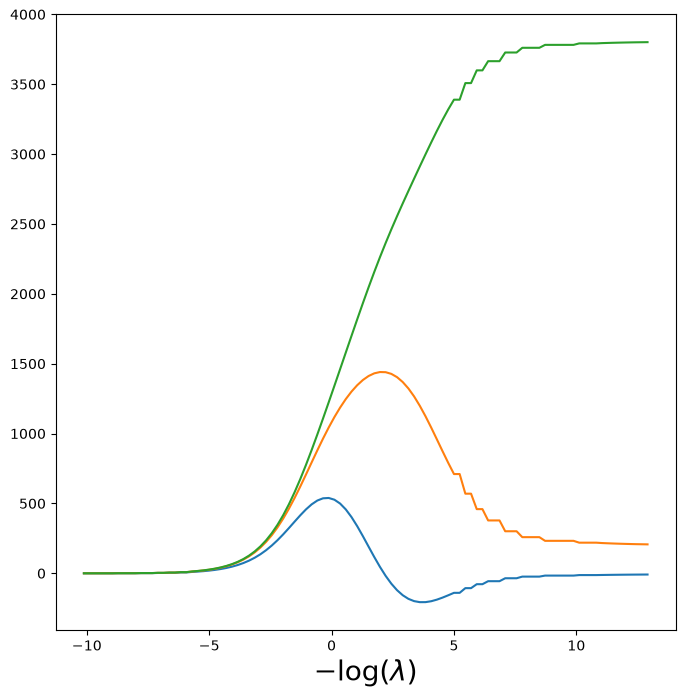

In [25]:
path_fig, ax = subplots(figsize=(8,8))
soln_path.plot(ax=ax, legend=False)
ax.set_xlabel('$-\log(\lambda)$', fontsize=20)

Adicionando rótulos, a legenda e extraindo as estimativas do 40º passo no caminho.

In [26]:
ax.set_ylabel('Standardized coefficients', fontsize=20)
ax.legend(loc='upper left');
beta_hat = soln_path.loc[soln_path.index[39]]
lambdas[39], beta_hat

(np.float64(2.84846259186263),
 AMBIENT_TEMPERATURE    457.002862
 MODULE_TEMPERATURE     706.193487
 IRRADIATION            775.146719
 Name: -1.046779407277964, dtype: float64)

Calculando a norma L2 dos coeficientes no 40º passo extraído anteriormente.

In [27]:
np.linalg.norm(beta_hat)

np.float64(1143.8589480294945)

Calculando a norma L2 em um passo mais avançado, correspondente a uma restrição (lambda) menor, revelando um aumento na magnitude dos coeficientes (principalmente o da `IRRADIATION`).

In [28]:
beta_hat = soln_path.loc[soln_path.index[59]]
lambdas[59], np.linalg.norm(beta_hat)

(np.float64(0.027189955709214435), np.float64(3155.6119723031948))

Usando a infraestrutura Pipeline do sklearn para isolar e automatizar o escalonamento dos dados (StandardScaler) da etapa de modelagem (ElasticNet / Ridge).

In [29]:
ridge = skl.ElasticNet(alpha=lambdas[59], l1_ratio=0)
scaler = StandardScaler(with_mean=True, with_std=True)
pipe = Pipeline(steps=[('scaler', scaler), ('ridge', ridge)])
pipe.fit(X, Y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,3
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value
"mean_ mean_: ndarray of shape (n_features,) or NoneThe mean value for each feature in the training set.Equal to ``None`` when ``with_mean=False`` and ``with_std=False``.","ndarray[float64](3,)","[25.56,31.24, 0.23]"


Confirmando que as normas L2 das variáveis calculadas pelo Pipeline fecham com os cálculos manuais da seção anterior.

In [30]:
np.linalg.norm(ridge.coef_)

np.float64(3155.587556790476)

Avaliação do MSE para estimar o Erro de Teste usando validação com partição randômica (50%) sob valor arbitrário de alpha igual a 0.01.

In [31]:
validation = skm.ShuffleSplit(n_splits=1, test_size=0.5, random_state=0)
ridge.alpha = 0.01
results = skm.cross_validate(ridge, X, Y, scoring='neg_mean_squared_error', cv=validation)
-results['test_score']

array([675613.34451044])

Testando novamente o erro agora com lambda extremamente alto (1e10), resultando virtualmente no modelo nulo (prever o `DC_POWER` apenas com base na sua média).

In [32]:
ridge.alpha = 1e10
results = skm.cross_validate(ridge, X, Y, scoring='neg_mean_squared_error', cv=validation)
-results['test_score']

array([16221251.7334301])

Realizando busca em grade exaustiva (GridSearchCV) no conjunto de validação para localizar automaticamente o melhor valor de penalização do Ridge.

In [33]:
param_grid = {'ridge__alpha': lambdas}
grid = skm.GridSearchCV(pipe, param_grid, cv=validation, scoring='neg_mean_squared_error')
grid.fit(X, Y)
grid.best_params_['ridge__alpha']
grid.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,3
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value
"mean_ mean_: ndarray of shape (n_features,) or NoneThe mean value for each feature in the training set.Equal to ``None`` when ``with_mean=False`` and ``with_std=False``.","ndarray[float64](3,)","[25.56,31.24, 0.23]"


Repetindo o mesmo processo da busca por grade, mas dessa vez avaliando os hiperparâmetros através da validação cruzada k-fold. Como temos muitas observações (68.774) e apenas 3 preditores, o risco de sobreajuste é baixo e o melhor lambda encontrado é muito pequeno, ou seja, o Ridge ótimo fica muito próximo da regressão de mínimos quadrados comum.

In [34]:
grid = skm.GridSearchCV(pipe, param_grid, cv=kfold, scoring='neg_mean_squared_error')
grid.fit(X, Y)
grid.best_params_['ridge__alpha']
grid.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,3
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value
"mean_ mean_: ndarray of shape (n_features,) or NoneThe mean value for each feature in the training set.Equal to ``None`` when ``with_mean=False`` and ``with_std=False``.","ndarray[float64](3,)","[25.56,31.24, 0.23]"


Plotando a estimativa do MSE baseada em Validação Cruzada versus a restrição -log(lambda) (eixo vertical em escala logarítmica, devido à magnitude do `DC_POWER`).

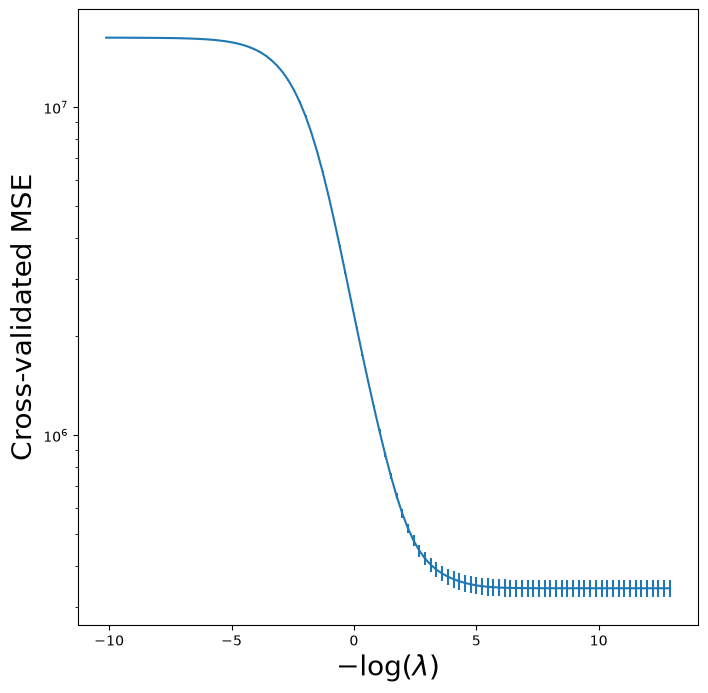

In [35]:
ridge_fig, ax = subplots(figsize=(8,8))
ax.errorbar(-np.log(lambdas), -grid.cv_results_['mean_test_score'], yerr=grid.cv_results_['std_test_score'] / np.sqrt(K))
ax.set_yscale('log')
ax.set_xlabel('$-\log(\lambda)$', fontsize=20)
ax.set_ylabel('Cross-validated MSE', fontsize=20);

Usando a proporção de variância (R²) como critério de escore no GridSearchCV para o conjunto invés do MSE padrão.

In [36]:
grid_r2 = skm.GridSearchCV(pipe, param_grid, cv=kfold)
grid_r2.fit(X, Y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...l1_ratio=0))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{'ridge__alpha': array([2.4774...47744750e-06])}
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosit

Plotando o R² validado em relação aos diferentes logaritmos negativos de lambda para monitorar qual produz o pico de capacidade explicativa. Com pouca penalização, o R² chega a aproximadamente 0,98, refletindo a forte relação entre irradiação e potência gerada.

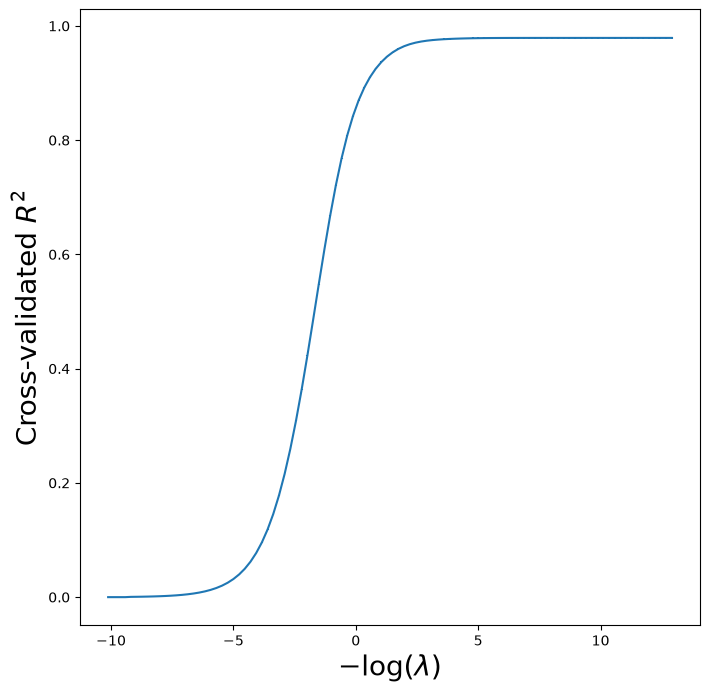

In [37]:
r2_fig, ax = subplots(figsize=(8,8))
ax.errorbar(-np.log(lambdas), grid_r2.cv_results_['mean_test_score'], yerr=grid_r2.cv_results_['std_test_score'] / np.sqrt(K))
ax.set_xlabel('$-\log(\lambda)$', fontsize=20)
ax.set_ylabel('Cross-validated $R^2$', fontsize=20);

Uma versão otimizada da Validação Cruzada em massa: ElasticNetCV constrói diretamente todo o caminho de lambda durante o fit sem sobrecarga das interfaces gerais do grid.

In [38]:
ridgeCV = skl.ElasticNetCV(alphas=lambdas, l1_ratio=0, cv=kfold)
pipeCV = Pipeline(steps=[('scaler', scaler), ('ridge', ridgeCV)])
pipeCV.fit(X, Y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,3
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value
"mean_ mean_: ndarray of shape (n_features,) or NoneThe mean value for each feature in the training set.Equal to ``None`` when ``with_mean=False`` and ``with_std=False``.","ndarray[float64](3,)","[25.56,31.24, 0.23]"


Recriando o gráfico do MSE da ferramenta CV veloz (ElasticNetCV) com a linha vertical pontilhada destacando o melhor lambda detectado por ela.

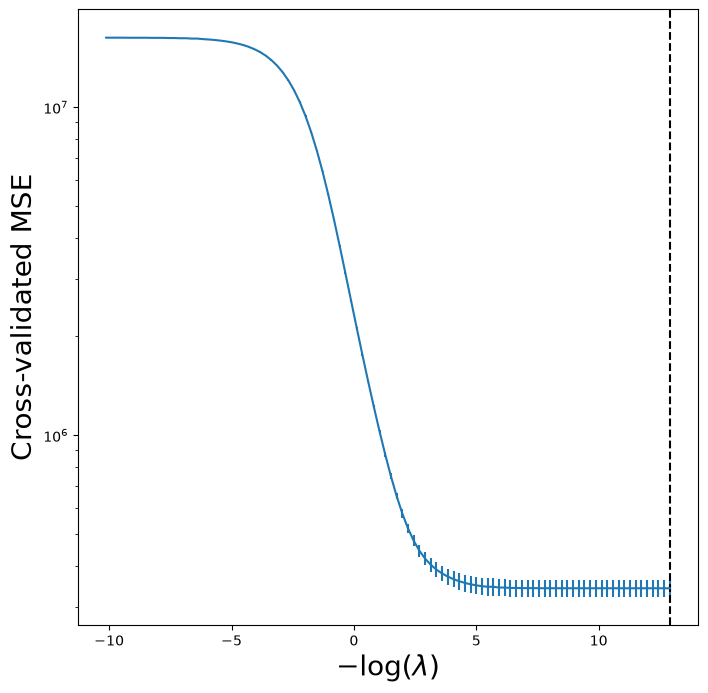

In [39]:
tuned_ridge = pipeCV.named_steps['ridge']
ridgeCV_fig, ax = subplots(figsize=(8,8))
ax.errorbar(-np.log(lambdas), tuned_ridge.mse_path_.mean(1), yerr=tuned_ridge.mse_path_.std(1) / np.sqrt(K))
ax.axvline(-np.log(tuned_ridge.alpha_), c='k', ls='--')
ax.set_yscale('log')
ax.set_xlabel('$-\log(\lambda)$', fontsize=20)
ax.set_ylabel('Cross-validated MSE', fontsize=20);

Extraindo o valor numérico exato do menor MSE captado na varredura cruzada das penalidades Ridge.

In [40]:
np.min(tuned_ridge.mse_path_.mean(1))

np.float64(341338.7167104425)

Extraindo os coeficientes ajustados em todo o dataset ao final da execução. Pode-se notar que Ridge não leva nenhum deles exatamente a zero: as três variáveis climáticas permanecem no modelo, com a `IRRADIATION` dominando amplamente.

In [41]:
tuned_ridge.coef_

array([  -8.40674971,  205.91405038, 3801.68950856])

Montando validação cruzada aninhada (Nested Cross-Validation): isolando os dados de teste na partição externa e deixando os folds de tuning inteiramente na parte interna para ter uma métrica justa.

In [42]:
outer_valid = skm.ShuffleSplit(n_splits=1, test_size=0.25, random_state=1)
inner_cv = skm.KFold(n_splits=5, shuffle=True, random_state=2)
ridgeCV = skl.ElasticNetCV(alphas=lambdas, l1_ratio=0, cv=inner_cv)
pipeCV = Pipeline(steps=[('scaler', scaler), ('ridge', ridgeCV)]);

Iniciando a avaliação aninhada que previne que vazamento de dados contamine nosso escore e exibindo o Test MSE.

In [43]:
results = skm.cross_validate(pipeCV, X, Y, cv=outer_valid, scoring='neg_mean_squared_error')
-results['test_score']

array([320574.27040819])

Passando para a implementação da penalização Lasso: mudamos a taxa l1_ratio para 1 e usamos a mesma mecânica de tuning para encontrar o modelo regularizado Lasso ideal. (Nas versões recentes do scikit-learn, o argumento `n_alphas` foi substituído por `alphas` recebendo um número inteiro.)

In [44]:
lassoCV = skl.ElasticNetCV(alphas=100, l1_ratio=1, cv=kfold)
pipeCV = Pipeline(steps=[('scaler', scaler), ('lasso', lassoCV)])
pipeCV.fit(X, Y)
tuned_lasso = pipeCV.named_steps['lasso']
tuned_lasso.alpha_

np.float64(4.282196024888804)

Processando uma listagem avulsa dos coeficientes da regressão Lasso para criar a trajetória individual e carregá-la em um DataFrame para exploração tabular e visual.

In [45]:
lambdas, soln_array = skl.Lasso.path(Xs, Y, l1_ratio=1, alphas=100)[:2]
soln_path = pd.DataFrame(soln_array.T, columns=D.columns, index=-np.log(lambdas))

Gerando o gráfico do caminho da regressão Lasso. Aqui você observa os coeficientes sendo comprimidos de forma que desapareçam da equação do modelo em níveis altos de penalidade. A `IRRADIATION` é a primeira variável a entrar no modelo e a última a sair, confirmando ser o preditor mais importante para o `DC_POWER`.

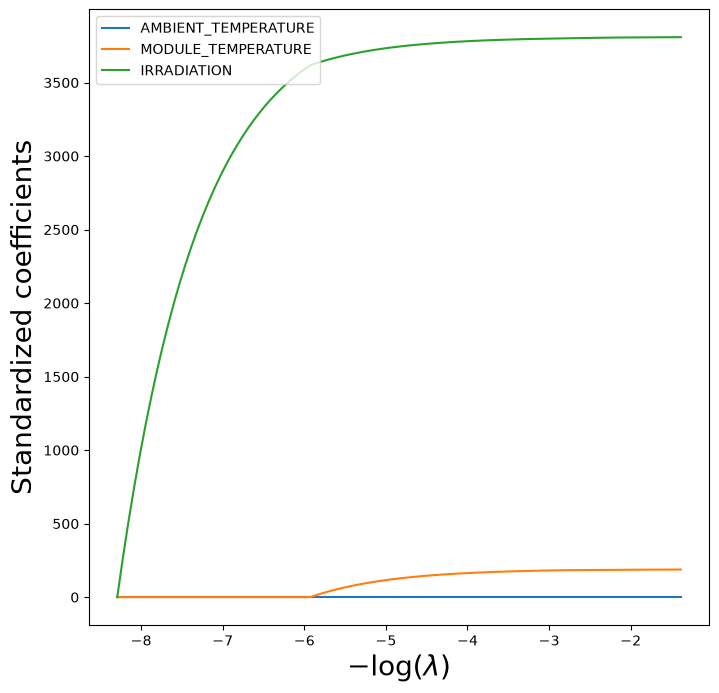

In [46]:
path_fig, ax = subplots(figsize=(8,8))
soln_path.plot(ax=ax, legend=False)
ax.legend(loc='upper left')
ax.set_xlabel('$-\log(\lambda)$', fontsize=20)
ax.set_ylabel('Standardized coefficients', fontsize=20);

Visualizando o erro Mínimo (MSE) do modelo sintonizado do Lasso na partição para validação cruzada.

In [47]:
np.min(tuned_lasso.mse_path_.mean(1))

np.float64(341305.8294017043)

Plotando a variação do erro CV para as seleções do modelo Lasso ao longo do intervalo testado no formato de gráfico de erro padrão.

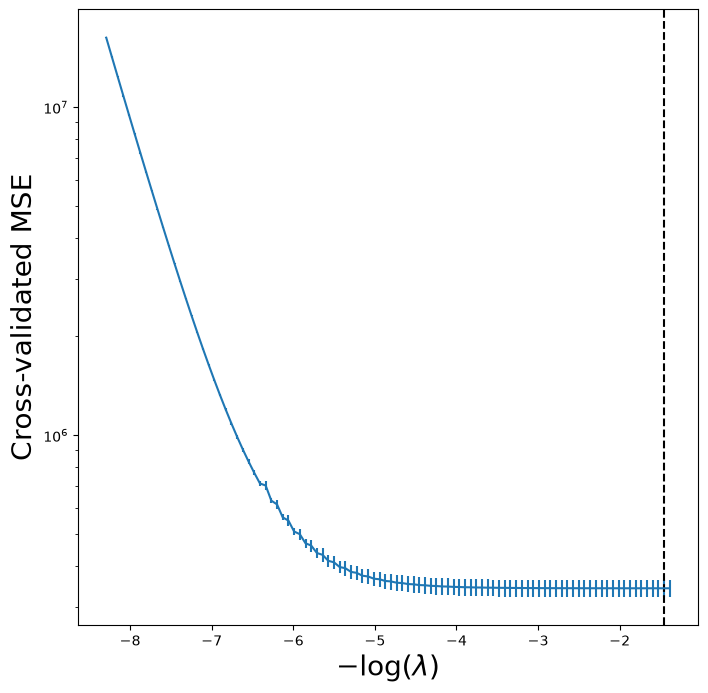

In [48]:
lassoCV_fig, ax = subplots(figsize=(8,8))
ax.errorbar(-np.log(tuned_lasso.alphas_), tuned_lasso.mse_path_.mean(1), yerr=tuned_lasso.mse_path_.std(1) / np.sqrt(K))
ax.axvline(-np.log(tuned_lasso.alpha_), c='k', ls='--')
ax.set_yscale('log')
ax.set_xlabel('$-\log(\lambda)$', fontsize=20)
ax.set_ylabel('Cross-validated MSE', fontsize=20);

Checando o array de coeficientes otimizados para revelar o aspecto chave do Lasso: a característica esparsa. Aqui o coeficiente da `AMBIENT_TEMPERATURE` é ajustado exatamente a zero, restando apenas `MODULE_TEMPERATURE` e `IRRADIATION` — o mesmo subconjunto escolhido pelo critério Cp e pela seleção do melhor subconjunto.

In [49]:
tuned_lasso.coef_

array([   0.        ,  189.41657841, 3807.18200017])

Executando a Regressão por Componentes Principais (PCR): extraindo 2 componentes usando PCA e os injetando em uma Regressão Linear padrão através da funcionalidade de Pipeline.

In [50]:
pca = PCA(n_components=2)
linreg = skl.LinearRegression()
pipe = Pipeline([('pca', pca), ('linreg', linreg)])
pipe.fit(X, Y)
pipe.named_steps['linreg'].coef_

array([ 302.73475797, -495.87561352])

Como a análise de PCA é sensível à variância das escalas (as temperaturas estão em °C, com valores na casa das dezenas, enquanto a irradiação varia entre 0 e ~1,2), inserimos uma camada primária de normalização com StandardScaler na reconstrução do modelo PCR.

In [51]:
pipe = Pipeline([('scaler', scaler), ('pca', pca), ('linreg', linreg)])
pipe.fit(X, Y)
pipe.named_steps['linreg'].coef_

array([ 2312.38493987, -2257.42871721])

Integrando o GridSearchCV à infraestrutura do PCR para iterar de 1 a 3 componentes (o número máximo, já que temos apenas 3 preditores) e escolher a quantidade ótima utilizando K-fold CV.

In [52]:
param_grid = {'pca__n_components': range(1, X.shape[1] + 1)}
grid = skm.GridSearchCV(pipe, param_grid, cv=kfold, scoring='neg_mean_squared_error')
grid.fit(X, Y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'pca__n_components': range(1, 4)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the 

Plotando os resultados da busca em grade do modelo de Regressão em Componentes Principais com o MSE como eixo principal dependente dos componentes. O menor erro ocorre com 3 componentes, que equivale à regressão linear com todos os preditores.

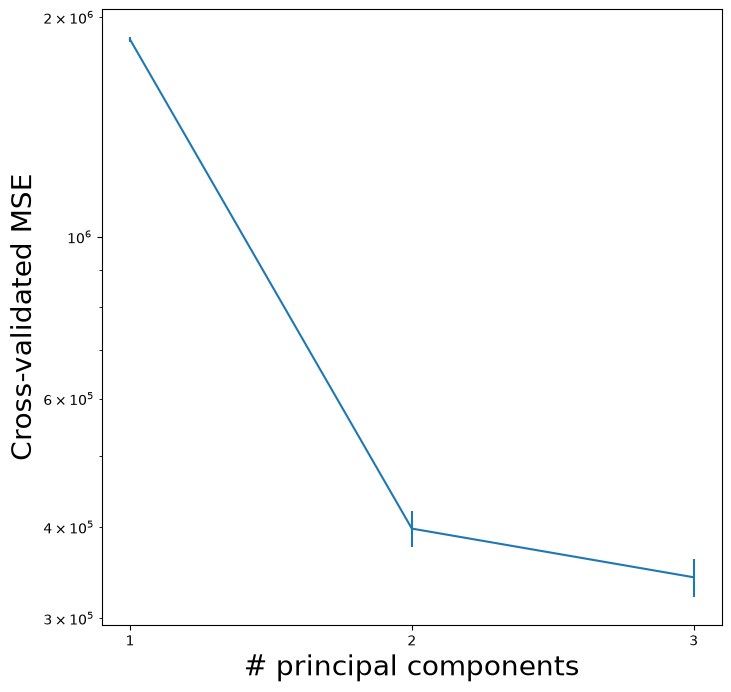

In [53]:
pcr_fig, ax = subplots(figsize=(8,8))
n_comp = param_grid['pca__n_components']
ax.errorbar(n_comp, -grid.cv_results_['mean_test_score'], grid.cv_results_['std_test_score'] / np.sqrt(K))
ax.set_ylabel('Cross-validated MSE', fontsize=20)
ax.set_xlabel('# principal components', fontsize=20)
ax.set_xticks(n_comp)
ax.set_yscale('log');

Avaliando em contrapartida um modelo sem preditores (matriz de zeros) e gerando o MSE dessa condição base, visto que a função PCA requer que n_components > 0. Esse MSE (≈ $1,6 \times 10^7$) corresponde à variância do `DC_POWER` e serve de referência para medir o ganho de cada modelo.

In [54]:
Xn = np.zeros((X.shape[0], 1))
cv_null = skm.cross_validate(linreg, Xn, Y, cv=kfold, scoring='neg_mean_squared_error')
-cv_null['test_score'].mean()

np.float64(16292982.459052226)

Analisando a razão da variância explicada agregada por cada componente principal. Como as três variáveis climáticas são fortemente correlacionadas, o 1º componente sozinho capta cerca de 90% da variância dos preditores e, com 2 componentes, chegamos a quase 99,5%.

In [55]:
pipe.named_steps['pca'].explained_variance_ratio_

array([0.8994827 , 0.09587859])

Ajustando o algoritmo de Regressão de Mínimos Quadrados Parciais (PLS), utilizando duas componentes e indicando a normalização do banco com 'scale=True'.

In [56]:
pls = PLSRegression(n_components=2, scale=True)
pls.fit(X, Y)

,"n_components n_components: int, default=2Number of components to keep. Should be in `[1, n_features]`.",2
,"scale scale: bool, default=TrueWhether to scale `X` and `y`.",True
,"max_iter max_iter: int, default=500The maximum number of iterations of the power method when`algorithm='nipals'`. Ignored otherwise.",500
,"tol tol: float, default=1e-06The tolerance used as convergence criteria in the power method: thealgorithm stops whenever the squared norm of `u_i - u_{i-1}` is lessthan `tol`, where `u` corresponds to the left singular vector.",1e-06
,"copy copy: bool, default=TrueWhether to copy `X` and `y` in :term:`fit` before applying centering,and potentially scaling. If `False`, these operations will be doneinplace, modifying both arrays.",True
Name,Type,Value
"coef_ coef_: ndarray of shape (n_target, n_features)The coefficients of the linear model such that `y` is approximated as`y = X @ coef_.T + intercept_`.","ndarray[float64](1, 3)","[[-148.17, 137.42,8988.51]]"
"intercept_ intercept_: ndarray of shape (n_targets,)The intercepts of the linear model such that `y` is approximated as`y = X @ coef_.T + intercept_`... versionadded:: 1.1","ndarray[float64](1,)",[3147.18]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,3
"n_iter_ n_iter_: list of shape (n_components,)Number of iterations of the power method, for eachcomponent.",list,"[1, 1]"
"x_loadings_ x_loadings_: ndarray of shape (n_features, n_components)The loadings of `X`.","ndarray[float64](3, 2)","[[ 0.54, 0.85], [ 0.61,-0.1 ], [ 0.59,-0.52]]"


Processando as interações automáticas do melhor hiperparâmetro de componentes PLS (de 1 a 3) dentro do universo do nosso Cross-Validation via Busca por Grade.

In [57]:
param_grid = {'n_components': range(1, X.shape[1] + 1)}
grid = skm.GridSearchCV(pls, param_grid, cv=kfold, scoring='neg_mean_squared_error')
grid.fit(X, Y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",PLSRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_components': range(1, 4)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of informa

Efetivando a última curva gráfica, apresentando a trajetória da variação do MSE à medida que são introduzidas mais componentes ao ajuste Mínimos Quadrados Parciais. Por considerar a resposta `DC_POWER` na construção dos componentes, o PLS atinge erros menores que o PCR com o mesmo número de componentes (1 e 2).

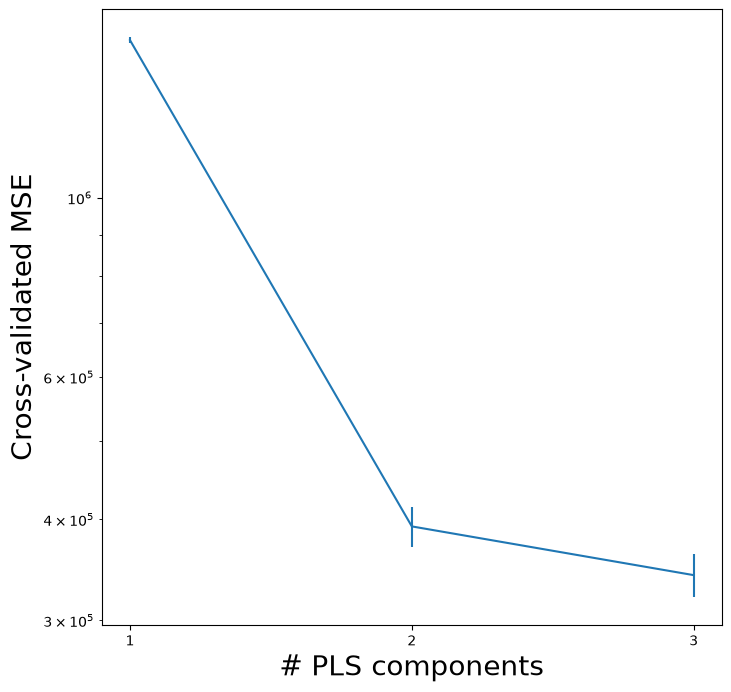

In [58]:
pls_fig, ax = subplots(figsize=(8,8))
n_comp = param_grid['n_components']
ax.errorbar(n_comp, -grid.cv_results_['mean_test_score'], grid.cv_results_['std_test_score'] / np.sqrt(K))
ax.set_ylabel('Cross-validated MSE', fontsize=20)
ax.set_xlabel('# PLS components', fontsize=20)
ax.set_xticks(n_comp)
ax.set_yscale('log');